In [6]:
import os
import time
import argparse
import numpy as np
from typing import Sequence
import gurobipy as gp

from dataset import fetch_data, DataTemplate
from eval import Evaluator
from model import LogisticRegression
from fair_fn import grad_ferm, grad_dp, loss_ferm, loss_dp
from utils import fix_seed, save2csv
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FixedLocator

In [7]:
def parse_args(dataset="adult", metric="eop", seed=None, alpha=None, beta=None, gamma=None):
    class Args:
        pass
    args = Args()
    args.dataset = dataset
    args.metric = metric
    args.seed = seed
    args.alpha = alpha
    args.beta = beta
    args.gamma = gamma
    return args

dataset="german"
metric = "eop"
beta_gamma = [0,0]
# Call the function with your desired arguments
if dataset=="adult" and metric=="dp":
    beta_gamma = [0.8,0.3]
if dataset=="adult" and metric=="eop":
    beta_gamma = [0.5,0.2]
if dataset=="german" and metric=="dp":
    beta_gamma = [0.5,0.0]
if dataset=="german" and metric=="eop":
    beta_gamma = [0.5,0] #0.0, 0.0
if dataset=="compas" and metric=="dp":
    beta_gamma = [0.3,0.1]
if dataset=="compas" and metric=="eop":
    beta_gamma = [0.3,0.1] #0.2,0.1
    
args = parse_args(dataset=dataset, metric=metric, seed=None, alpha=None, beta=beta_gamma[0], gamma=beta_gamma[1])

In [8]:
def lp(fair_infl: Sequence, util_infl: Sequence, fair_loss: float, alpha: float, beta: float,
       gamma: float) -> np.ndarray:
    num_sample = len(fair_infl)
    max_fair = sum([v for v in fair_infl if v < 0.])
    max_util = sum([v for v in util_infl if v < 0.])

    print("Maximum fairness promotion: %.5f; Maximum utility promotion: %.5f;" % (max_fair, max_util))

    all_one = np.array([1. for _ in range(num_sample)])
    fair_infl = np.array(fair_infl)
    util_infl = np.array(util_infl)
    model = gp.Model()
    x = model.addMVar(shape=(num_sample,), lb=0, ub=1)

    if fair_loss >= -max_fair:
        print("=====> Fairness loss exceeds the maximum availability")
        model.addConstr(util_infl @ x <= 0. * max_util, name="utility")
        model.addConstr(all_one @ x <= alpha * num_sample, name="amount")
        model.setObjective(fair_infl @ x)
        model.optimize()
    else:
        model.addConstr(fair_infl @ x <= beta * -fair_loss, name="fair")
        model.addConstr(util_infl @ x <= gamma * max_util, name="util")
        model.setObjective(all_one @ x)
        model.optimize()

    print("Total removal: %.5f; Ratio: %.3f%%\n" % (sum(x.X), (sum(x.X) / num_sample) * 100))

    return 1 - x.X

In [9]:

tik = time.time()

if args.seed is not None:
    fix_seed(args.seed)

""" initialization"""

data: DataTemplate = fetch_data(args.dataset)
model = LogisticRegression(l2_reg=data.l2_reg)
val_evaluator, test_evaluator = Evaluator(data.s_val, "val"), Evaluator(data.s_test, "test")
print(data.s_val)

Loading German dataset..
Dataset statistic - #total: 1000; #train: 600; #val.: 200; #test: 200; #dim.: 56

[1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0.
 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0. 1. 0.
 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1.
 1. 0. 0. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0.
 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1.
 0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1.
 0. 1. 1. 0. 1. 0. 1. 1.]


In [10]:


""" vanilla training """

model.fit(data.x_train, data.y_train)
scale_list = [0.001, 0.01, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
#scale_list = [1]
scale_dict_values_val = {}
scale_dict_values_test = {}
for scale in scale_list:
    original_weights = model.model.coef_
    original_intercept = model.model.intercept_
    scaled_weights = original_weights * scale
    scaled_intercept = original_intercept * scale
    scaled_weights = original_weights * scale
    scaled_intercept = original_intercept * scale
    model.model.coef_ = scaled_weights
    model.model.intercept_ = scaled_intercept

    if args.metric == "eop":
        ori_fair_loss_val = loss_ferm(model.log_loss, data.x_val, data.y_val, data.s_val)
    elif args.metric == "dp":
        pred_val, _ = model.pred(data.x_val)
        ori_fair_loss_val = loss_dp(data.x_val, data.s_val, pred_val)
    else:
        raise ValueError
    ori_util_loss_val = model.log_loss(data.x_val, data.y_val)

    """ compute the influence and solve lp """

    pred_train, _ = model.pred(data.x_train)

    train_total_grad, train_indiv_grad = model.grad(data.x_train, data.y_train)
    util_loss_total_grad, acc_loss_indiv_grad = model.grad(data.x_val, data.y_val)
    if args.metric == "eop":
        fair_loss_total_grad = grad_ferm(model.grad, data.x_val, data.y_val, data.s_val)
    elif args.metric == "dp":
        fair_loss_total_grad = grad_dp(model.grad_pred, data.x_val, data.s_val)
    else:
        raise ValueError

    hess = model.hess(data.x_train)
    util_grad_hvp = model.get_inv_hvp(hess, util_loss_total_grad)
    fair_grad_hvp = model.get_inv_hvp(hess, fair_loss_total_grad)

    util_pred_infl = train_indiv_grad.dot(util_grad_hvp)
    fair_pred_infl = train_indiv_grad.dot(fair_grad_hvp)

    sample_weight = lp(fair_pred_infl, util_pred_infl, ori_fair_loss_val, args.alpha, args.beta, args.gamma)

    """ train with weighted samples """

    model.fit(data.x_train, data.y_train, sample_weight=sample_weight)

    if args.metric == "eop":
        upd_fair_loss_val = loss_ferm(model.log_loss, data.x_val, data.y_val, data.s_val)
    elif args.metric == "dp":
        pred_val, _ = model.pred(data.x_val)
        upd_fair_loss_val = loss_dp(data.x_val, data.s_val, pred_val)
    else:
        raise ValueError
    upd_util_loss_val = model.log_loss(data.x_val, data.y_val)

    print("Fairness loss: %.5f -> %.5f; Utility loss: %.5f -> %.5f" % (
        ori_fair_loss_val, upd_fair_loss_val, ori_util_loss_val, upd_util_loss_val))

    _, pred_label_val = model.pred(data.x_val)
    _, pred_label_test = model.pred(data.x_test)

    val_res = val_evaluator(data.y_val, pred_label_val)
    test_res = test_evaluator(data.y_test, pred_label_test)
    scale_dict_values_val[scale] = val_res
    scale_dict_values_test[scale] = test_res
    tok = time.time()
    print("Total time: %.5fs" % (tok - tik))

Maximum fairness promotion: -0.95002; Maximum utility promotion: -32.54443;
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "AlmaLinux 9.5 (Teal Serval)")

CPU model: AMD EPYC 7763 64-Core Processor, instruction set [SSE2|AVX|AVX2]
Thread count: 128 physical cores, 128 logical processors, using up to 32 threads

Optimize a model with 2 rows, 600 columns and 1200 nonzeros (Min)
Model fingerprint: 0xc35fd917
Model has 600 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-05, 6e-01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e-04, 2e-04]
Presolve removed 0 rows and 150 columns
Presolve time: 0.00s
Presolved: 2 rows, 450 columns, 900 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.544444e-03   0.000000e+00      0s
       3    2.0202056e-02   0.000000e+00   0.000000e+00      0s

Solved in 3 iterations and 0.01 seconds (0.00 work units)
Optimal objectiv

/home/cyadav/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/cyadav/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/cyadav/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/cyadav/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic

Total removal: 2.00913; Ratio: 0.335%

Fairness loss: 0.03825 -> 0.39880; Utility loss: 134.45201 -> 136.05034
------------------------------ Results on val
Grp. 0 - #instance: 77; #pos. pred: 27; Acc.: 0.623377
Grp. 1 - #instance: 123; #pos. pred: 73; Acc.: 0.699187
Overall acc.: 0.670000; Demographic parity: 0.242847; Equal opportunity: 0.217391
------------------------------ Results on test
Grp. 0 - #instance: 81; #pos. pred: 31; Acc.: 0.604938
Grp. 1 - #instance: 119; #pos. pred: 66; Acc.: 0.697479
Overall acc.: 0.660000; Demographic parity: 0.171906; Equal opportunity: 0.183853
Total time: 0.27483s
Maximum fairness promotion: -0.88752; Maximum utility promotion: -32.82254;
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "AlmaLinux 9.5 (Teal Serval)")

CPU model: AMD EPYC 7763 64-Core Processor, instruction set [SSE2|AVX|AVX2]
Thread count: 128 physical cores, 128 logical processors, using up to 32 threads

Optimize a model with 2 rows, 600 columns and 1200 nonzeros (Mi

/home/cyadav/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/cyadav/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/cyadav/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/cyadav/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic

Maximum fairness promotion: -0.93851; Maximum utility promotion: -47.68168;
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "AlmaLinux 9.5 (Teal Serval)")

CPU model: AMD EPYC 7763 64-Core Processor, instruction set [SSE2|AVX|AVX2]
Thread count: 128 physical cores, 128 logical processors, using up to 32 threads

Optimize a model with 2 rows, 600 columns and 1200 nonzeros (Min)
Model fingerprint: 0x1af34904
Model has 600 linear objective coefficients
Coefficient statistics:
  Matrix range     [7e-06, 2e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 1e-01]
Presolve removed 0 rows and 96 columns
Presolve time: 0.00s
Presolved: 2 rows, 504 columns, 1008 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.098889e+00   0.000000e+00      0s
       3    1.0525510e+01   0.000000e+00   0.000000e+00      0s

Solved in 3 iterations and 0.01 seconds (0.00 work units)
Optimal objectiv

/home/cyadav/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [11]:
def plotting(x_values, scale_dict_values, string_for_val_test, logflag, metric, dataset):
    x_values = scale_list
    y_values = []
    y_value_at_scale1 = -10000
    print(scale_dict_values)
    for key, values_dict in scale_dict_values.items():
        if key==1.0:
            print('inside key=1.0')
            y_value_at_scale1= values_dict[metric]
            y_values.append(values_dict[metric])
        else:
            y_values.append(values_dict[metric])
    print(y_value_at_scale1)
    # Plotting
    plt.plot(x_values, y_values, marker='o', linestyle='-')

    plt.xticks(x_values, x_values)

    # Set logarithmic scale for x-axis
    if logflag:
        plt.xscale('log')

    plt.axhline(y=y_value_at_scale1, color='r', linestyle='--', label=metric+' w/o attack')  # Add dashed line
    plt.legend()

    plt.xlabel('Scaling Coefficient')
    plt.ylabel(metric+' value')
    plt.grid(True)
    if logflag:
        plt.savefig('plots/'+dataset+'/log_'+string_for_val_test+'_'+metric+'_scaling.pdf')
    else:
        plt.savefig('plots/'+dataset+'/'+string_for_val_test+'_'+metric+'_scaling.pdf')
    plt.show()

{0.001: {'overall_acc': 0.67, 'dp': 0.24284658430999895, 'eop': 0.21739130434782605, 'grp_0_acc': 0.6233766233766234, 'grp_1_acc': 0.6991869918699187}, 0.01: {'overall_acc': 0.67, 'dp': 0.24284658430999895, 'eop': 0.21739130434782605, 'grp_0_acc': 0.6233766233766234, 'grp_1_acc': 0.6991869918699187}, 0.05: {'overall_acc': 0.67, 'dp': 0.24284658430999895, 'eop': 0.21739130434782605, 'grp_0_acc': 0.6233766233766234, 'grp_1_acc': 0.6991869918699187}, 0.08: {'overall_acc': 0.67, 'dp': 0.24284658430999895, 'eop': 0.21739130434782605, 'grp_0_acc': 0.6233766233766234, 'grp_1_acc': 0.6991869918699187}, 0.1: {'overall_acc': 0.67, 'dp': 0.24284658430999895, 'eop': 0.21739130434782605, 'grp_0_acc': 0.6233766233766234, 'grp_1_acc': 0.6991869918699187}, 0.2: {'overall_acc': 0.675, 'dp': 0.22985957132298596, 'eop': 0.19565217391304346, 'grp_0_acc': 0.6363636363636364, 'grp_1_acc': 0.6991869918699187}, 0.3: {'overall_acc': 0.68, 'dp': 0.20061239573434697, 'eop': 0.16304347826086962, 'grp_0_acc': 0.64

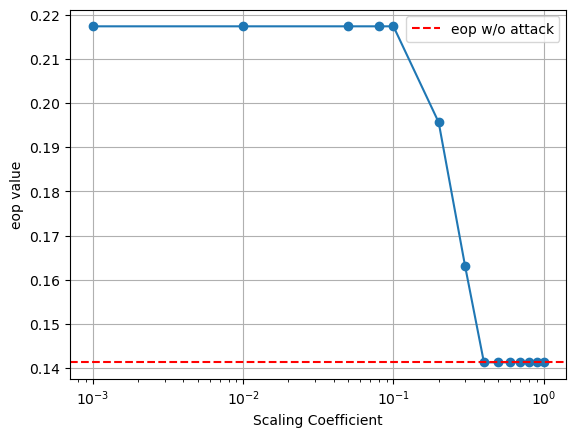

In [12]:
plotting(scale_list, scale_dict_values_val, 'val', True, args.metric, dataset)
# plotting(scale_list, scale_dict_values_val, 'val', False, args.metric, dataset)
# plotting(scale_list, scale_dict_values_test, 'test', True, args.metric, dataset)
# plotting(scale_list, scale_dict_values_test, 'test', False, args.metric, dataset)

# plotting(scale_list, scale_dict_values_val, 'val', False, 'overall_acc', dataset)
# plotting(scale_list, scale_dict_values_val, 'val', True, 'overall_acc', dataset)
# plotting(scale_list, scale_dict_values_test, 'test', False, 'overall_acc', dataset)
# plotting(scale_list, scale_dict_values_test, 'test', True, 'overall_acc', dataset)

In [13]:
title_dict = {"adult":"Adult Credit", "german": "German Credit", "compas":"Compas"}

eop 0.13010092145677932
overall_acc 0.655
Line2D(EOP (after attack)) EOP (after attack)
Line2D(EOP (w/o attack)) EOP (w/o attack)


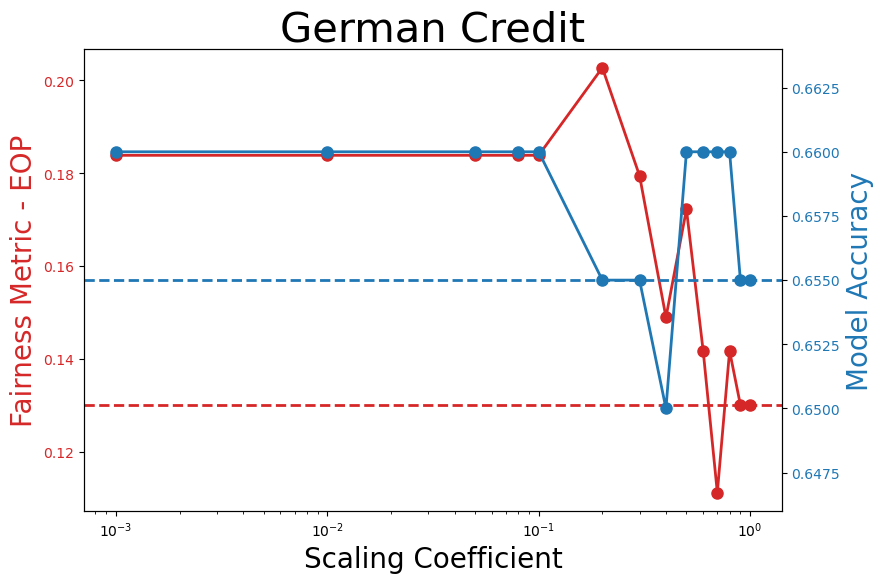

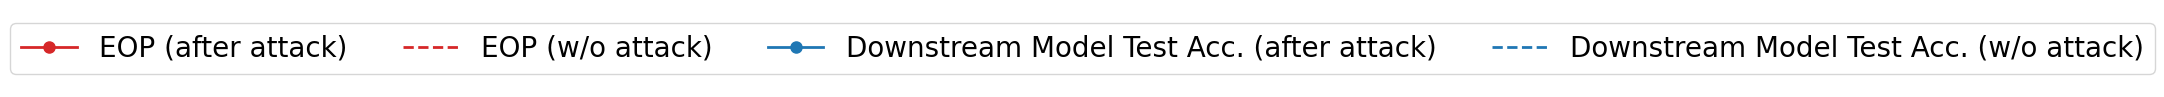

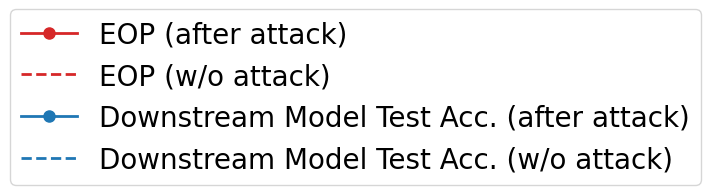

In [18]:
fontsize=20
title_fontsize=30
display_metric = {"dp": "Demographic Parity Gap", "eop": "Fairness Metric - EOP", "overall_acc": "Model Accuracy"}
fig, ax1 = plt.subplots(figsize=(9, 6))
ax2 = ax1.twinx()
color_list = ['tab:red', 'tab:blue']
linewidth = 2
markersize = 8
leg = None
setused="test"
for metric, ax, color in zip(["eop", "overall_acc"], [ax1, ax2], color_list):
    scale_dict_values = scale_dict_values_test
    x_values = scale_list
    y_values = []
    y_value_at_scale1 = -10000
    for key, values_dict in scale_dict_values.items():
        if key==1.0:
            y_value_at_scale1= values_dict[metric]
            y_values.append(values_dict[metric])
        else:
            y_values.append(values_dict[metric])
    print(metric, y_value_at_scale1)
    
    if metric=='dp':
        lns1 = ax.plot(x_values, y_values, marker='o', linestyle='-', label= "Demographic Parity Gap (after attack)", color=color, linewidth=linewidth, markersize=markersize)
        lns2 = ax.axhline(y=y_value_at_scale1, linestyle='--', label='Demographic Parity Gap (w/o attack)', color=color, linewidth=linewidth, markersize=markersize)
    elif metric=='eop':
        lns1 = ax.plot(x_values, y_values, marker='o', linestyle='-', label= "EOP (after attack)", color=color, linewidth=linewidth, markersize=markersize)
        lns2 = ax.axhline(y=y_value_at_scale1, linestyle='--', label='EOP (w/o attack)', color=color, linewidth=linewidth, markersize=markersize)
    else:
        lns1 = ax.plot(x_values, y_values, marker='o', linestyle='-', label= "Downstream Model Test Acc. (after attack)", color=color, linewidth=linewidth, markersize=markersize)
        lns2 = ax.axhline(y=y_value_at_scale1, linestyle='--', label='Downstream Model Test Acc. (w/o attack)', color=color, linewidth=linewidth, markersize=markersize)
        
    if leg is None:
        leg = lns1
    else:
        leg += lns1
    leg.append(lns2)
    
    if metric == "overall_acc":
        ax.set_ylabel(display_metric[metric], fontsize=fontsize, color=color)
    else:
        ax.set_ylabel(display_metric[metric], fontsize=fontsize, color=color)
    ax.tick_params(axis='y', labelcolor=color)
    new_ymin = min(min(y_values)-0.004, y_value_at_scale1-0.004)
    new_ymax = max(max(y_values)+0.004, y_value_at_scale1+0.004)
    ax.set_ylim(new_ymin, new_ymax)
    #ax.set_ylim(min(y_values)-0.004, max(y_values)+0.004)
    
    
labs = [l.get_label() for l in leg]
# ax1.legend(leg, labs, fontsize=fontsize-5)
ax1.set_xlabel('Scaling Coefficient', fontsize=fontsize)
plt.xscale('log')
plt.title(title_dict[dataset], fontsize = title_fontsize)
plt.savefig(f"plots/{dataset}_{setused}_eop_acc_new.pdf", bbox_inches='tight')
# plt.legend(fontsize=fontsize-5)

leg_handles = []
labels = []
for leg_handle, label in zip(*ax1.get_legend_handles_labels()):
    print(leg_handle, label)
    leg_handles.append(leg_handle)
    labels.append(label)
    
for leg_handle, label in zip(*ax2.get_legend_handles_labels()):
    leg_handles.append(leg_handle)
    labels.append(label)

figsize = (5, 1)
fig_leg = plt.figure(figsize=figsize)
legend_properties = {'size': fontsize}
ax_leg = fig_leg.add_subplot(111)
ax_leg.legend(*(leg_handles, labels), loc='center', ncol=4, prop=legend_properties)
ax_leg.axis('off')
#     plt.show()
fig_leg.savefig('plots/fairness_legend_new.pdf', bbox_inches = 'tight')

figsize = (5, 1)
fig_leg = plt.figure(figsize=figsize)
legend_properties = {'size': fontsize}
ax_leg = fig_leg.add_subplot(111)
ax_leg.legend(*(leg_handles, labels), loc='center', ncol=1, prop=legend_properties)
ax_leg.axis('off')
#     plt.show()
fig_leg.savefig('plots/fairness_legend_vertical_new.pdf', bbox_inches = 'tight')


In [15]:
#print(ax1.get_legend_handles_labels())
#print(tuple(list(ax1.get_legend_handles_labels()) + list(ax2.get_legend_handles_labels())))

In [16]:
# fontsize=25
# title_fontsize = 30
# display_metric = {"dp": "DP", "eop": "EOP", "overall_acc": "Model Accuracy"}
# fig, ax1 = plt.subplots(figsize=(9, 6))
# ax2 = ax1.twinx()
# color_list = ['tab:red', 'tab:blue']
# linewidth = 2
# markersize = 8
# leg = None
# setused="test"
# for metric, ax, color in zip(["eop", "overall_acc"], [ax1, ax2], color_list):
#     scale_dict_values = scale_dict_values_test
#     x_values = scale_list
#     y_values = []
#     y_value_at_scale1 = -10000
#     for key, values_dict in scale_dict_values.items():
#         if key==1.0:
#             y_value_at_scale1= values_dict[metric]
#             y_values.append(values_dict[metric])
#         else:
#             y_values.append(values_dict[metric])
            
#     print(metric)
#     if metric=='dp' or metric=='eop':
#         lns1 = ax.plot(x_values, y_values, marker='o', linestyle='-', label= "Fairness Metric (after attack)", color=color, linewidth=linewidth, markersize=markersize)
#         lns2 = ax.axhline(y=y_value_at_scale1, linestyle='--', label='Fairness Metric (w/o attack)', color=color, linewidth=linewidth, markersize=markersize)
#     else:
#         lns1 = ax.plot(x_values, y_values, marker='o', linestyle='-', label= "Model Accuracy (after attack)", color=color, linewidth=linewidth, markersize=markersize)
#         lns2 = ax.axhline(y=y_value_at_scale1, linestyle='--', label='Model Accuracy (w/o attack)', color=color, linewidth=linewidth, markersize=markersize)
        
# #     lns1 = ax.plot(x_values, y_values, marker='o', linestyle='-', label= "fairness metric (after attack)", color=color, linewidth=linewidth, markersize=markersize)
# #     lns2 = ax.axhline(y=y_value_at_scale1, linestyle='--', label='fairness metric (w/o attack)', color=color, linewidth=linewidth, markersize=markersize)
    
#     if leg is None:
#         leg = lns1
#     else:
#         leg += lns1
#     leg.append(lns2)
    
#     if metric == "overall_acc":
#         ax.set_ylabel(display_metric[metric], fontsize=fontsize, color=color)
#     else:
#         ax.set_ylabel("Fairness Metric - "+display_metric[metric], fontsize=fontsize, color=color)
#     ax.tick_params(axis='y', labelcolor=color)
#     new_ymin = min(min(y_values)-0.004, y_value_at_scale1-0.004)
#     new_ymax = max(max(y_values)+0.004, y_value_at_scale1+0.004)
#     ax.set_ylim(new_ymin, new_ymax)
#     #ax.set_ylim(min(y_values)-0.004, max(y_values)+0.004)
    
    
# labs = [l.get_label() for l in leg]
# # ax1.legend(leg, labs, fontsize=fontsize-5)
# ax1.set_xlabel('Scaling Coefficient', fontsize=fontsize)
# plt.xscale('log')
# plt.title(title_dict[dataset], fontsize=title_fontsize)
# plt.savefig(f"plots/{dataset}_{setused}_eop_acc_new.pdf", bbox_inches='tight')
# # plt.legend(fontsize=fontsize-5)

# leg_handles = []
# labels = []
# for leg_handle, label in zip(*ax1.get_legend_handles_labels()):
#     print(leg_handle, label)
#     leg_handles.append(leg_handle)
#     labels.append(label)
    
# for leg_handle, label in zip(*ax2.get_legend_handles_labels()):
#     leg_handles.append(leg_handle)
#     labels.append(label)

# figsize = (5, 1)
# fig_leg = plt.figure(figsize=figsize)
# legend_properties = {'size': fontsize}
# ax_leg = fig_leg.add_subplot(111)
# ax_leg.legend(*(leg_handles, labels), loc='center', ncol=4, prop=legend_properties)
# ax_leg.axis('off')
# #     plt.show()
# fig_leg.savefig('plots/fairness_legend_new.pdf', bbox_inches = 'tight')

# figsize = (5, 1)
# fig_leg = plt.figure(figsize=figsize)
# legend_properties = {'size': fontsize}
# ax_leg = fig_leg.add_subplot(111)
# ax_leg.legend(*(leg_handles, labels), loc='center', ncol=1, prop=legend_properties)
# ax_leg.axis('off')
# #     plt.show()
# fig_leg.savefig('plots/fairness_legend_vertical_new.pdf', bbox_inches = 'tight')
